# Stacking Classifier 

## 0. Import Necessary Modules

### Import Torch 

In [1]:
import torch

if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    x = torch.ones(1, device=mps_device)
    print(x)
else:
    print("MPS device not found.")

tensor([1.], device='mps:0')


In [2]:
device = "mps" if torch.mps.is_available() else "cpu"
print(f"✅ Using device: {device}")

✅ Using device: mps


### Import Other Libraries 

In [3]:
# Data Analysis Libraries
import pandas as pd
import numpy as np
from IPython.display import HTML, display
from pprint import pprint

# Data Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 7)

# Machine Learning Libraries
from tqdm import tqdm  # progress bar
import sklearn  # scikit-learn

# Data Preparation and Evaluation Libraries
import src.data_preprocess as dp
import src.evaluation as ev

print(f"Current pandas version: {pd.__version__}")

Current pandas version: 2.0.3


## 1. Data Preprocessing 

### Train Test Split 

In [4]:
df = pd.read_csv("data/processed/creditcard_cleaned.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
# some stats about the data
print(f"Number of Data Points: {df.size}")
print(f"Number of Fradulent Transactions: {df['Class'].value_counts()[1]}")
print(f"Number of Non-Fradulent Transactions: {df['Class'].value_counts()[0]}\n")

Number of Data Points: 8795506
Number of Fradulent Transactions: 473
Number of Non-Fradulent Transactions: 283253



In [6]:
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)
y = df["Class"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [7]:
# - Check Class Distribution -
print(y_train.value_counts())
print("==========================")
print(y_test.value_counts())

Class
0    226602
1       378
Name: count, dtype: int64
Class
0    56651
1       95
Name: count, dtype: int64


### Feature Scaling 

In [8]:
# - Scaling of Train, Validation, Test Data  -
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()  # set_output(transform="pandas") shouldn't work here (Conversion to Tensor won't work)

# - Train StandardScaler() based on features in Train Data -
X_train_scaled = scaler.fit_transform(X_train)

# - Apply Learning to Test Data -
X_test_scaled = scaler.transform(X_test)

In [9]:
# - Check Scaling Validity Manually -
dp.check_scaling_validity(X_train_scaled)
dp.check_scaling_validity(X_test_scaled)

Feature means after scaling:
 0.04211337257935192

Feature std devs after scaling:
 1.4115090716241605
Feature means after scaling:
 0.04118829144075911

Feature std devs after scaling:
 1.4687385481030577


## 2. Load LightGBM Model 

In [10]:
import joblib

# Load LightGBM model
lightgbm_model = joblib.load("models/lightgbm.pkl")
print(f"Loaded {type(lightgbm_model).__name__}")

Loaded Pipeline


In [11]:
# Evaluate ensemble
from sklearn.metrics import classification_report, fbeta_score, roc_auc_score

y_pred_lightgbm = lightgbm_model.predict(X_test_scaled)

f2_ensemble = fbeta_score(y_test, y_pred_lightgbm, beta=2)
auc_ensemble = roc_auc_score(y_test, y_pred_lightgbm)

print(f"LightGBM  - F2: {f2_ensemble:.4f}, AUC: {auc_ensemble:.4f}")
print("\nClassification Report:")
print(
    classification_report(y_test, y_pred_lightgbm, target_names=["Non-Fraud", "Fraud"])
)

/Users/lunlun/Downloads/Github/Fraud-Detection-ML/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM  - F2: 0.7771, AUC: 0.8997

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56651
       Fraud       0.70      0.80      0.75        95

    accuracy                           1.00     56746
   macro avg       0.85      0.90      0.87     56746
weighted avg       1.00      1.00      1.00     56746



## 2. PyTorch MLP Model

In [12]:
from src.modeling.models import FraudNN

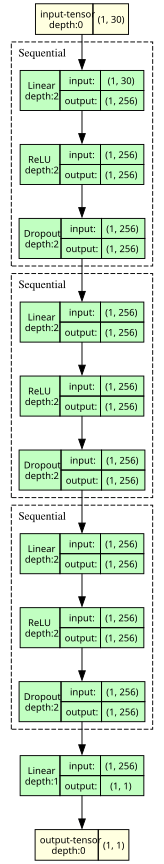

In [13]:
import torch
from torchview import draw_graph
from src.modeling.models import FraudNN

# Load model
checkpoint = torch.load(
    "models/pytorch_mlp_fraud_model.pth", map_location="cpu", weights_only=False
)
model_state_dict = checkpoint["model_state_dict"]
best_hyperparams = checkpoint["hyperparameters"]

model = FraudNN(**best_hyperparams)
model.load_state_dict(model_state_dict)
model.eval()


model_graph = draw_graph(
    model,
    input_size=(1, 30),
    expand_nested=True,
    save_graph=False,
    filename="fraud_model",
)

# Display
display(model_graph.visual_graph)


In [14]:
best_hyperparams

{'input_features': 30,
 'hidden_units': 256,
 'num_layers': 2,
 'dropout_rate': 0.1495870713458829,
 'learning_rate': 0.0004818211096601037,
 'threshold': 0.546455928615033}

### Sklearn Wrapper

In [15]:
from sklearn.base import BaseEstimator, ClassifierMixin


class PreTrainedFraudNN(BaseEstimator, ClassifierMixin):
    def __init__(self, model_path):
        self.model_path = model_path
        self.threshold = 0.5
        self.model_ = None

    def fit(self, X, y=None):
        checkpoint = torch.load(self.model_path, map_location="cpu", weights_only=False)
        hyperparams = checkpoint["hyperparameters"]

        self.model_ = FraudNN(**hyperparams)
        self.model_.load_state_dict(checkpoint["model_state_dict"])
        self.model_.eval()

        self.threshold = hyperparams["threshold"]
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X):
        X_tensor = torch.tensor(X.astype("float32"), dtype=torch.float32)
        with torch.no_grad():
            logits = self.model_(X_tensor).squeeze()
            probs = torch.sigmoid(logits).numpy()
        return np.column_stack([1 - probs, probs])

    def predict(self, X):
        probs = self.predict_proba(X)[:, 1]
        return (probs > self.threshold).astype(int)


# Set the estimator type attribute
PreTrainedFraudNN._estimator_type = "classifier"

# Initialize models
mlp_nn = PreTrainedFraudNN("models/pytorch_mlp_fraud_model.pth")
mlp_nn.fit(X_train_scaled.astype("float32"), y_train.astype("float32"))

,model_path,'models/pytorch_mlp_fraud_model.pth'


In [16]:
# Test PyTorch model
from sklearn.metrics import fbeta_score, roc_auc_score, average_precision_score

y_pred_nn = mlp_nn.predict(X_test_scaled.astype("float32"))
y_proba_nn = mlp_nn.predict_proba(X_test_scaled.astype("float32"))[:, 1]

f2 = fbeta_score(y_test, y_pred_nn, beta=2)
auc = roc_auc_score(y_test, y_proba_nn)

print(f"PyTorch MLP - F2: {f2:.4f}, AUC: {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn, target_names=["Non-Fraud", "Fraud"]))


PyTorch MLP - F2: 0.7794, AUC: 0.9524

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56651
       Fraud       0.68      0.81      0.74        95

    accuracy                           1.00     56746
   macro avg       0.84      0.90      0.87     56746
weighted avg       1.00      1.00      1.00     56746



## 3. Create Stacking Classifier

### Defining Stacking Classifier & Meta-Model

In [17]:
from sklearn.ensemble import StackingClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_class_weight


# Create stacking
stacking_clf = StackingClassifier(
    estimators=[("lgb", lightgbm_model), ("mlp", mlp_nn)],
    final_estimator=LogisticRegression(),
    cv="prefit",
)

stacking_clf.fit(
    X_train_scaled, y_train
)  # fit final estimator on base models' predictions to smartly learn patterns


/Users/lunlun/Downloads/Github/Fraud-Detection-ML/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,estimators,"[('lgb', ...), ('mlp', ...)]"
,final_estimator,LogisticRegression()
,cv,'prefit'
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,boosting_type,'gbdt'


### Stacking Classifier Prediction 

In [18]:
y_pred_stacking = stacking_clf.predict(X_test_scaled.astype("float32"))
y_proba_stacking = stacking_clf.predict_proba(X_test_scaled.astype("float32"))[:, 1]

/Users/lunlun/Downloads/Github/Fraud-Detection-ML/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/lunlun/Downloads/Github/Fraud-Detection-ML/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Results

In [19]:
# Evaluate ensemble
from sklearn.metrics import classification_report, fbeta_score, roc_auc_score

f2_ensemble = fbeta_score(y_test, y_pred_stacking, beta=2)
auc_ensemble = roc_auc_score(y_test, y_proba_stacking)

print(f"Ensemble - F2: {f2_ensemble:.4f}, AUC: {auc_ensemble:.4f}")
print("\nClassification Report:")
print(
    classification_report(y_test, y_pred_stacking, target_names=["Non-Fraud", "Fraud"])
)

Ensemble - F2: 0.7957, AUC: 0.9771

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56651
       Fraud       0.87      0.78      0.82        95

    accuracy                           1.00     56746
   macro avg       0.94      0.89      0.91     56746
weighted avg       1.00      1.00      1.00     56746



✅ Stacking Classifier Results Analysis
Accuracy:  0.9994
Precision: 0.8706
Recall:    0.7789
F1-Score:  0.8222
ROC-AUC:   0.9771
PR-AUC:    0.8282

✅ Classification Report:
              precision    recall  f1-score   support

           0     0.9996    0.9998    0.9997     56651
           1     0.8706    0.7789    0.8222        95

    accuracy                         0.9994     56746
   macro avg     0.9351    0.8894    0.9110     56746
weighted avg     0.9994    0.9994    0.9994     56746

--------------------

✅ Confusion Matrix:


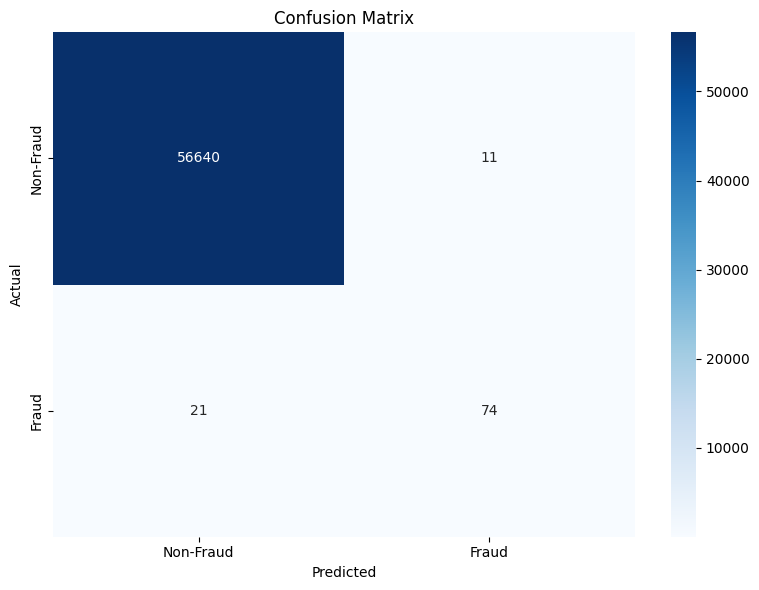

{'accuracy': 0.9994360836006062,
 'precision': 0.8705882352941177,
 'recall': 0.7789473684210526,
 'f1_score': 0.8222222222222222,
 'roc_auc': 0.9770849959446992,
 'pr_auc': 0.8282400187499914}

In [21]:
ev.ResultsAnalyser().analyze_predictions(y_test, y_pred_stacking, y_proba_stacking, model_name='Stacking Classifier')